In [92]:
!pip install pandas matplotlib seaborn nltk sqlalchemy

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from sqlalchemy import create_engine

In [94]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [95]:
df = pd.read_csv("USvideos.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35349 entries, 0 to 35348
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                35349 non-null  object
 1   trending_date           35349 non-null  object
 2   title                   35349 non-null  object
 3   channel_title           35349 non-null  object
 4   category_id             35349 non-null  int64 
 5   publish_time            35349 non-null  object
 6   tags                    35349 non-null  object
 7   views                   35349 non-null  int64 
 8   likes                   35349 non-null  int64 
 9   dislikes                35349 non-null  int64 
 10  comment_count           35349 non-null  int64 
 11  thumbnail_link          35349 non-null  object
 12  comments_disabled       35349 non-null  bool  
 13  ratings_disabled        35349 non-null  bool  
 14  video_error_or_removed  35349 non-null  bool  
 15  de

In [96]:
df.drop_duplicates(inplace=True)

df.dropna(subset=['title'], inplace=True)

# Fix trending_date format (VERY IMPORTANT)
df['trending_date'] = pd.to_datetime(
    df['trending_date'],
    format='%y.%d.%m'
)

# Fix publish_time
df['publish_time'] = pd.to_datetime(df['publish_time'])

# Add country column
df['country'] = 'US'

df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,country
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13 17:13:01+00:00,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,US
1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00+00:00,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",US
2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12 19:05:24+00:00,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,US
3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13 11:00:04+00:00,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,US
4,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12 18:01:41+00:00,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,US


In [97]:
df.drop_duplicates(inplace=True)
df.dropna(subset=['title'], inplace=True)

df['trending_date'] = pd.to_datetime(
    df['trending_date'],
    format='%y.%d.%m'
)

df['publish_time'] = pd.to_datetime(df['publish_time'])
df['publish_time'] = df['publish_time'].dt.tz_localize(None)

df['country'] = 'US'

In [98]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

df['sentiment_score'] = df['title'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)

def get_sentiment(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['sentiment_score'].apply(get_sentiment)

df[['title','sentiment']].head()

,title,sentiment
0,WE WANT TO TALK ABOUT OUR MARRIAGE,Positive
1,The Trump Presidency: Last Week Tonight with J...,Neutral
2,"Racist Superman | Rudy Mancuso, King Bach & Le...",Negative
3,Nickelback Lyrics: Real or Fake?,Negative
4,I Dare You: GOING BALD!?,Neutral


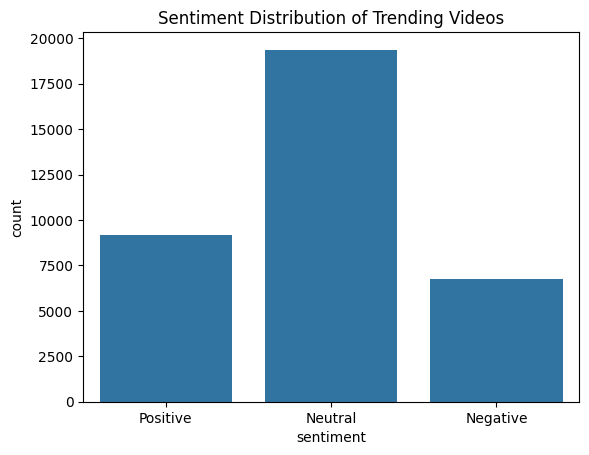

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='sentiment')
plt.title("Sentiment Distribution of Trending Videos")
plt.show()

In [100]:
from sqlalchemy import create_engine

engine = create_engine('sqlite:///youtube.db')

df.to_sql('youtube_data', engine, if_exists='replace', index=False)

35301

In [101]:
query = """
SELECT category_id,
       AVG(views) as avg_views,
       COUNT(video_id) as total_videos
FROM youtube_data
GROUP BY category_id
ORDER BY avg_views DESC
"""

result = pd.read_sql(query, engine)
result

,category_id,avg_views,total_videos
0,10,4.822861e+06,5240
1,29,3.462797e+06,48
2,1,2.396742e+06,1976
3,17,1.869420e+06,1962
4,20,1.847253e+06,562
5,24,1.846954e+06,8490
6,23,1.397144e+06,2988
7,2,1.359279e+06,380
8,22,1.268822e+06,2892
9,28,1.039742e+06,2148


In [102]:
result.to_csv("category_ranking.csv", index=False)

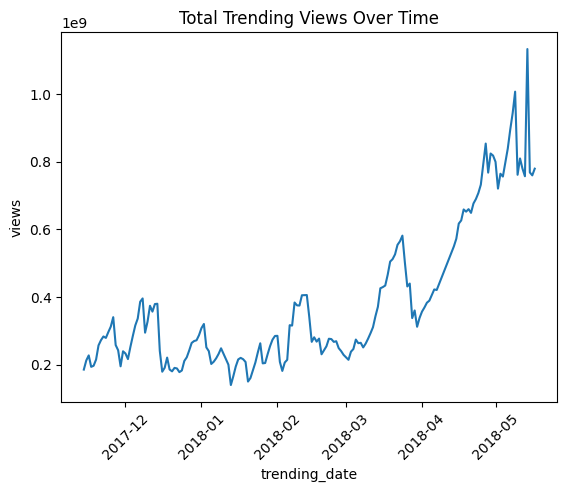

In [103]:
df_daily = df.groupby('trending_date')['views'].sum().reset_index()

sns.lineplot(data=df_daily, x='trending_date', y='views')
plt.xticks(rotation=45)
plt.title("Total Trending Views Over Time")
plt.show()

In [104]:
df['engagement_rate'] = (
    df['likes'] + df['comment_count']
) / df['views']

In [105]:
df.sort_values('engagement_rate', ascending=False).head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,country,sentiment_score,sentiment,engagement_rate
10200,LsoLEjrDogU,2018-01-04,Bruno Mars - Finesse (Remix) [Feat. Cardi B] [...,Bruno Mars,10,2018-01-04 04:49:43,"Bruno Mars|""Finesse""|""Cardi B""|""Finesse Remix""...",548621,159356,2374,19455,https://i.ytimg.com/vi/LsoLEjrDogU/default.jpg,False,False,False,Finesse (Remix) Feat. Cardi B Available Now: h...,US,0.0000,Neutral,0.325928
22174,8O_MwlZ2dEg,2018-03-07,j-hope 'Airplane' MV,ibighit,10,2018-03-06 15:00:10,"BIGHIT|""빅히트""|""방탄소년단""|""BTS""|""BANGTAN""|""방탄""",5275672,1401915,6268,158127,https://i.ytimg.com/vi/8O_MwlZ2dEg/default.jpg,False,False,False,j-hope 'Airplane' MV\n\n\n\nj-hope - 'Hope Wor...,US,0.0000,Neutral,0.295705
608,TyHvyGVs42U,2017-11-17,"Luis Fonsi, Demi Lovato - Échame La Culpa",LuisFonsiVEVO,10,2017-11-17 05:00:01,"Luis|""Fonsi""|""Demi""|""Lovato""|""Échame""|""La""|""Cu...",499946,135292,3528,12094,https://i.ytimg.com/vi/TyHvyGVs42U/default.jpg,False,False,False,"Music video by Luis Fonsi, Demi Lovato perform...",US,0.0000,Neutral,0.294804
19780,UaAHl_m_ybk,2018-02-23,5 Seconds Of Summer - Want You Back (Audio),5SOSVEVO,10,2018-02-23 00:00:01,"Seconds|""Of""|""Summer""|""Want""|""You""|""Back""|""Cap...",439056,106536,656,20575,https://i.ytimg.com/vi/UaAHl_m_ybk/default.jpg,False,False,False,Music video by 5 Seconds Of Summer performing ...,US,0.0772,Positive,0.289510
14428,9vDdx1dba6c,2018-01-27,dodie - Secret For The Mad,dodieVEVO,10,2018-01-26 18:00:15,"dodie|""Secret""|""For""|""The""|""Mad""|""Ditto""|""Musi...",129130,32755,98,2964,https://i.ytimg.com/vi/9vDdx1dba6c/default.jpg,False,False,False,Directed and animated by \nHannah Jacobs - htt...,US,-0.4939,Negative,0.276613


In [106]:
df.to_csv("final_youtube_cleaned.csv", index=False)